C:\Users\charl\AppData\Local\Temp\ipykernel_2732\2513951030.py:126: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_sex = df.dropna(subset=["성별"]).groupby("성별").apply(wmean)
C:\Users\charl\AppData\Local\Temp\ipykernel_2732\2513951030.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_age = df.dropna(subset=["연령"]).groupby("연령").apply(wmean).reindex(age_order)


        국내 숙박, 교통, 식음료비(%)  면세 상품 구입 경비(%)  일반 상품 구입 경비(%)  기타(%)
구분                                                               
전체                    64.7             8.9             6.8   19.6
남자                    64.4             9.3             6.2   20.2
여자                    65.1             8.4             7.4   19.0
15~19세                67.3             5.4             5.3   22.1
20대                   53.0            10.8             5.9   30.3
30대                   60.9             9.3             5.9   23.9
40대                   66.9             9.7             6.7   16.7
50대                   69.2             9.3             7.0   14.5
60대                   73.7             5.8            10.0   10.5
70세 이상                73.9             5.2             5.4   15.5


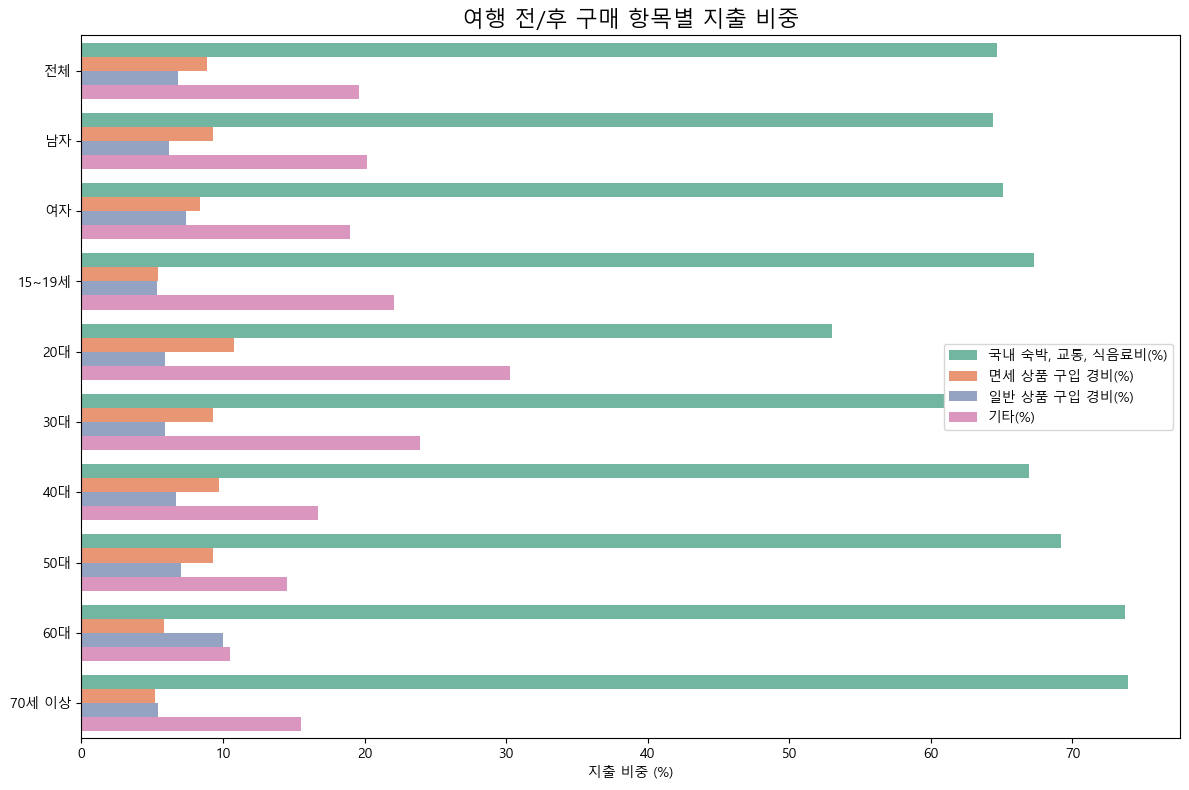

In [4]:
# -*- coding: utf-8 -*-
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rcParams

# =========================================
# 0) 한글 깨짐 방지 (운영체제별 자동 폰트 선택)
# =========================================
def set_korean_font():
    candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic", "DejaVu Sans"]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            rcParams["font.family"] = name
            break
    rcParams["axes.unicode_minus"] = False

set_korean_font()

# =========================================
# 1) 데이터 불러오기 (헤더 스캔 → 필요한 컬럼만 부분 로드)
# =========================================
xlsx_path = "./data/2024_해외.xlsx"
sheet = "RAWDATA"
header_row = 1  # 0-based 기준 2줄째가 변수명

# 1-1) 헤더만 먼저 읽어서 실제 컬럼명을 확보
cols_preview = pd.read_excel(
    xlsx_path, sheet_name=sheet, header=header_row, nrows=0
).columns.tolist()

# 1-2) 필요한 변수 패턴 정의
# 기본 인구학/가중치
base_cols = [c for c in ["BSEX", "BAGE", "WT_OVER"] if c in cols_preview]

# 국내 이동·식음료 (AA7_2_1~AA7_2_3)
dom_cols = [c for c in ["AA7_2_1", "AA7_2_2", "AA7_2_3"] if c in cols_preview]

# 일반 상품 구입 (AA7_2_4~AA7_2_11)
goods_cols = [f"AA7_2_{i}" for i in range(4, 12) if f"AA7_2_{i}" in cols_preview]

# 기타 (AA7_2_12~AA7_2_15)
other_cols = [f"AA7_2_{i}" for i in range(12, 16) if f"AA7_2_{i}" in cols_preview]

# 면세 상품 구입 (AA7_1_* : 면세점 지출)
dutyfree_cols = [c for c in cols_preview if re.fullmatch(r"AA7_1_\d+", c)]

# 로드 대상 최종 컬럼
use_cols = base_cols + dom_cols + goods_cols + other_cols + dutyfree_cols

# 실제 로드
df = pd.read_excel(
    xlsx_path,
    sheet_name=sheet,
    header=header_row,
    usecols=use_cols
)

# =========================================
# 2) 전처리: 성별/연령 라벨, 금액 합계 → 비중(%) 계산
# =========================================
sex_map = {1: "남자", 2: "여자"}
age_map = {
    1: "15~19세", 2: "20대", 3: "30대", 4: "40대",
    5: "50대", 6: "60대", 7: "70세 이상"
}
df["성별"] = df["BSEX"].map(sex_map) if "BSEX" in df.columns else np.nan
df["연령"] = df["BAGE"].map(age_map) if "BAGE" in df.columns else np.nan

# 금액 합계 (없으면 0으로 대체)
def rowsum(cols):
    return df[cols].sum(axis=1, skipna=True) if cols else 0

sum_dom = rowsum(dom_cols)         # 국내 숙박+교통/주차+식음료
sum_goods = rowsum(goods_cols)     # 일반 상품 구입
sum_other = rowsum(other_cols)     # 기타(대여/로밍/보험/기타)
sum_duty = rowsum(dutyfree_cols)   # 면세 상품 구입(면세점 지출)

total = sum_dom + sum_goods + sum_other + sum_duty

# 총액이 0인 응답 제외
mask = total > 0
df = df.loc[mask].copy()
total = total[mask]
sum_dom = sum_dom[mask]
sum_goods = sum_goods[mask]
sum_other = sum_other[mask]
sum_duty = sum_duty[mask]

# 비중(%) 컬럼 생성
df["국내 숙박, 교통, 식음료비(%)"] = (sum_dom / total) * 100
df["면세 상품 구입 경비(%)"]     = (sum_duty / total) * 100
df["일반 상품 구입 경비(%)"]     = (sum_goods / total) * 100
df["기타(%)"]                   = (sum_other / total) * 100

# =========================================
# 3) 요약 테이블: 전체 / 성별 / 연령 (가중치 있으면 가중평균)
# =========================================
value_cols = [
    "국내 숙박, 교통, 식음료비(%)",
    "면세 상품 구입 경비(%)",
    "일반 상품 구입 경비(%)",
    "기타(%)"
]
wcol = "WT_OVER" if "WT_OVER" in df.columns else None

def wmean(frame):
    if wcol and wcol in frame.columns:
        w = frame[wcol].astype(float)
        w = w / w.replace(0, np.nan)  # 0 방지용
        out = {}
        for c in value_cols:
            out[c] = np.average(frame[c], weights=frame[wcol])
        return pd.Series(out)
    else:
        return frame[value_cols].mean()

# (1) 전체
overall = wmean(df)
overall.name = "전체"

# (2) 성별
by_sex = df.dropna(subset=["성별"]).groupby("성별").apply(wmean)

# (3) 연령
age_order = ["15~19세", "20대", "30대", "40대", "50대", "60대", "70세 이상"]
by_age = df.dropna(subset=["연령"]).groupby("연령").apply(wmean).reindex(age_order)

# 최종 표
table = pd.concat([overall.to_frame().T, by_sex, by_age])
table.index.name = "구분"
table = table.round(1)
print(table)

# =========================================
# 4) 시각화 (수평 막대, 그룹=구분, Hue=지출 항목)
# =========================================
plot_df = (
    table.reset_index()
         .melt(id_vars="구분", var_name="지출 항목", value_name="비율")
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=plot_df, x="비율", y="구분",
    hue="지출 항목", orient="h", palette="Set2", errorbar=None
)
plt.title("여행 전/후 구매 항목별 지출 비중", fontsize=16)
plt.xlabel("지출 비중 (%)")
plt.ylabel("")
plt.legend(title="")
plt.tight_layout()
plt.savefig("travel_expense_share_by_group.png", dpi=300)
plt.show()
